# Text Mining Engine: Subrogation Indicator Extraction

This notebook walks through the heuristic NLP layer in `src/text_engine.py`:

1. How individual notes are scanned (including negation handling)
2. Running the engine across the full synthetic portfolio
3. Measuring precision and recall against the generator's hidden ground truth
4. Why precision drops on the "not referred" population

> Run `python data/mock_data_generator.py` first so the input CSVs exist.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
sys.path.insert(0, os.path.join(ROOT, 'src'))
from text_engine import scan_text, run_engine, INDICATORS, NEGATIONS

DATA = os.path.join(ROOT, 'data', 'output')
pd.set_option('display.max_colwidth', 90)

## 1. Scanning individual notes
Each note is split into sentences. Any sentence that matches a negation or insured-at-fault pattern is discarded before indicator matching.

In [2]:
examples = [
    "Insured unit was rear-ended while stopped at a red light on I-95.",
    "Insured driver rear-ended the claimant vehicle; insured at fault.",
    "Engineer report attributes loss to a defective valve on the boiler.",
    "Inspection of the valve found no evidence of defect; normal wear and tear.",
    "No evidence of defect in the pump. Separately, faulty wiring found in the panel.",
    "Other vehicle was tailgating and collided with the rear of insured's trailer.",
]
rows = []
for t in examples:
    hits, neg = scan_text(t)
    rows.append({'note': t, 'negated': neg,
                 'hits': ', '.join(f'{c} ({w})' for c, _, w in hits) or '-'})
pd.DataFrame(rows)

,note,negated,hits
0,Insured unit was rear-ended while stopped at a red light on I-95.,False,auto_rear_end (85)
1,Insured driver rear-ended the claimant vehicle; insured at fault.,True,-
2,Engineer report attributes loss to a defective valve on the boiler.,False,product_defect (85)
3,Inspection of the valve found no evidence of defect; normal wear and tear.,True,-
4,"No evidence of defect in the pump. Separately, faulty wiring found in the panel.",True,product_defect (70)
5,Other vehicle was tailgating and collided with the rear of insured's trailer.,False,-


The last example is a genuine rear-end loss written in wording the dictionary does not cover. It is missed, which is why recall is below 100%.

In [3]:
print(f"Indicator rules: {sum(len(v) for v in INDICATORS.values())} across {len(INDICATORS)} categories")
print(f"Negation rules:  {len(NEGATIONS)}")

Indicator rules: 27 across 6 categories
Negation rules:  8


## 2. Run across the portfolio

In [4]:
notes = pd.read_csv(os.path.join(DATA, 'adjuster_notes.csv'))
indicators = run_engine(notes)
indicators.to_csv(os.path.join(DATA, 'nlp_claim_indicators.csv'), index=False)
print(f"{len(notes):,} notes -> {len(indicators):,} claims, "
      f"{(indicators.INDICATOR_SCORE > 0).sum():,} with at least one indicator")
indicators[indicators.INDICATOR_SCORE > 0].head()

220,484 notes -> 50,000 claims, 13,109 with at least one indicator


,CLAIM_ID,INDICATOR_SCORE,PRIMARY_CATEGORY,TOP_PHRASE,MATCHED_PHRASES,HIT_COUNT,DISTINCT_CATEGORIES,NEGATION_FLAG,FIRST_INDICATOR_DATE,NOTES_SCANNED
1,CLM0000002,90,contractor_negligence,improper installation,hvac contractor; improper installation; subcontractor,3,1,N,2025-06-19,4
5,CLM0000006,85,auto_rear_end,rear-ended,rear-ended,1,1,N,2025-05-16,3
13,CLM0000014,85,auto_third_party_fault,ran a red light,ran a red light,1,1,N,2024-12-26,3
17,CLM0000018,85,auto_rear_end,rear-ended,rear-ended,1,1,N,2026-03-19,5
18,CLM0000019,85,auto_third_party_fault,other driver at fault,other driver at fault,1,1,N,2026-09-06,3


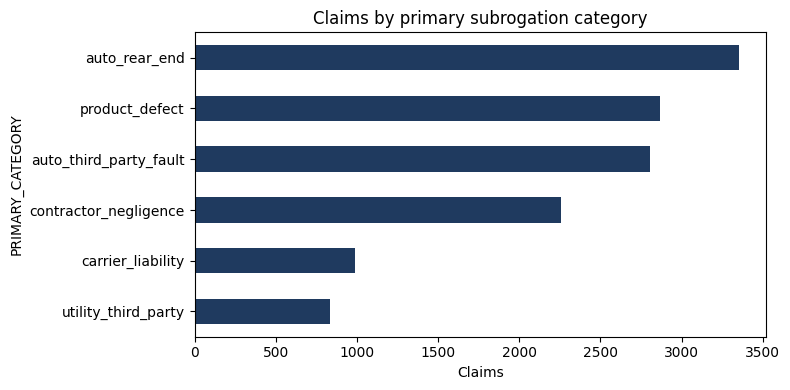

In [5]:
counts = indicators['PRIMARY_CATEGORY'].value_counts().sort_values()
ax = counts.plot.barh(figsize=(8, 4), color='#1f3a5f')
ax.set_title('Claims by primary subrogation category')
ax.set_xlabel('Claims')
plt.tight_layout(); plt.show()

## 3. Accuracy against ground truth
The generator records which claims genuinely had third-party liability (`ground_truth_subro.csv`). That file is used only for evaluation and is never loaded into the warehouse.

In [6]:
truth = pd.read_csv(os.path.join(DATA, 'ground_truth_subro.csv'))
m = indicators.merge(truth, on='CLAIM_ID')

def evaluate(df, threshold):
    pred = df.INDICATOR_SCORE >= threshold
    actual = df.TRUE_SUBRO_POTENTIAL == 1
    tp = (pred & actual).sum()
    return {'threshold': threshold, 'flagged': int(pred.sum()),
            'precision': round(tp / max(pred.sum(), 1), 3),
            'recall': round(tp / max(actual.sum(), 1), 3)}

pd.DataFrame([evaluate(m, t) for t in [40, 50, 60, 70, 80]])

,threshold,flagged,precision,recall
0,40,13109,0.950,0.831
1,50,13109,0.950,0.831
2,60,12947,0.962,0.831
3,70,11912,0.978,0.777
4,80,9844,1.000,0.657


A threshold of **60** is used downstream in `REF_RUN_CONFIG`: it removes most weak single-keyword hits without losing recall.

## 4. Precision on the population that matters
Overall precision is high because most true positives were already referred by adjusters. The leakage calculation only looks at **closed files that were not referred**, and that population is where the ambiguous cases concentrate.

In [7]:
claims = pd.read_csv(os.path.join(DATA, 'claims_master.csv'))
mm = m.merge(claims[['CLAIM_ID', 'CLAIM_STATUS', 'SUBROGATION_FLAG']], on='CLAIM_ID')
not_referred = mm[(mm.CLAIM_STATUS == 'Closed') & (mm.SUBROGATION_FLAG == 'No')]
pd.DataFrame([
    {'population': 'All claims', **evaluate(mm, 60)},
    {'population': 'Closed, not referred', **evaluate(not_referred, 60)},
])[['population', 'flagged', 'precision', 'recall']]

,population,flagged,precision,recall
0,All claims,12947,0.962,0.831
1,"Closed, not referred",1218,0.635,0.835


**Takeaway:** leakage estimates are an upper bound. Before a reopen campaign, a subrogation specialist should sample the flagged files. The triage score adds financial, recovery-rate, and SOL signals on top of the NLP score, which is why P1 queue items are far more precise than the raw indicator alone.